This notebook aims to debug my current ccsa custom implementation and check wheter my adaptation can make it more parameter-independent. We will first focus on diminishing the potential differences with the NLOPT implementation, then provide possible alternatives for the adaptation of parameters like the trust region, the curvature, w, parameter for the control of the curvature update. Finally we will understand how stochasticity affects this and how we can change the acceptance criterion to be suitable for stochastic optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch

## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

[82.50106044914597]


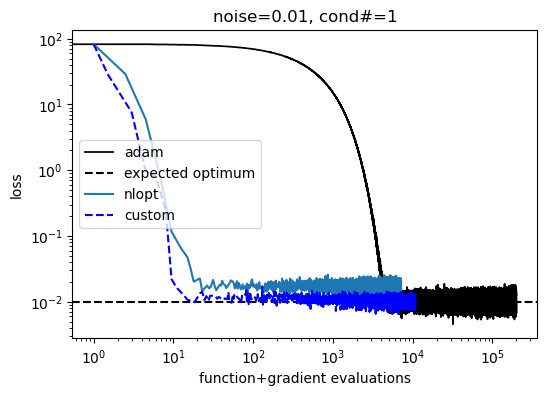

/Users/antoniovaragnolo/Desktop/Research/CCSA/ccsa/optimizer.py:469: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax3.scatter(i, f_hist[i], color=color, edgecolor='k', s=70, marker=marker, zorder=10)


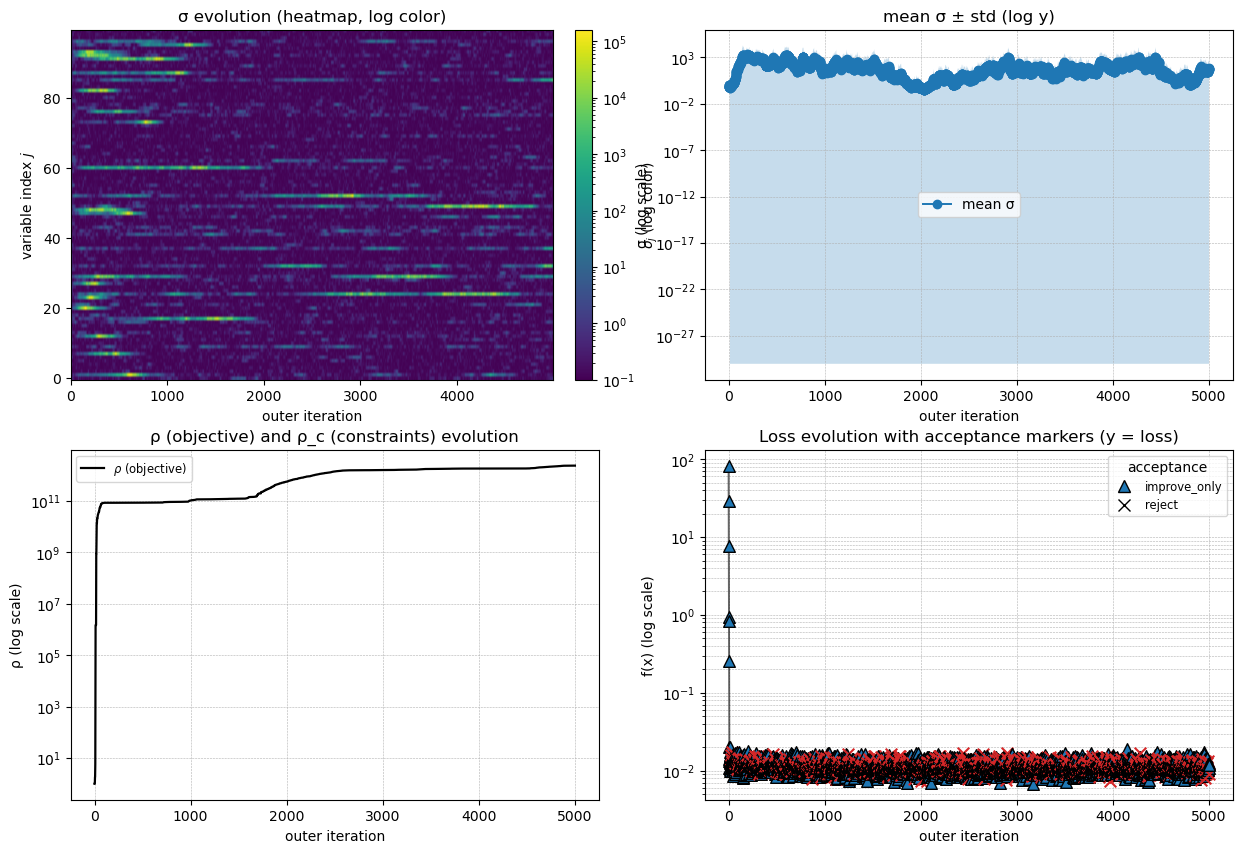

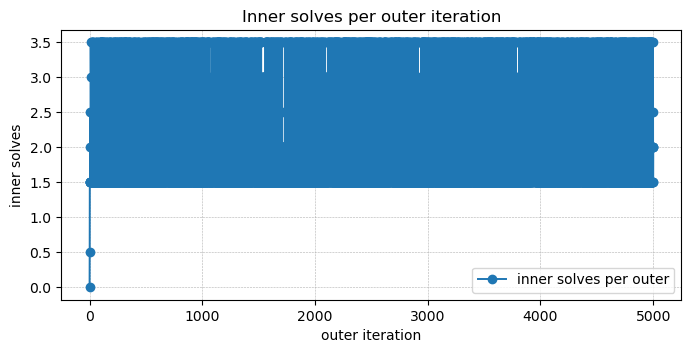


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 5001
Sigma: final mean = 4.255e+01, final std = 2.455e+02
Rho (objective): final = 2.299e+12

Acceptance counts:
Counter({'improve_only': 4137, 'reject': 863})

Average inner solves per outer step (observed): 2.15


In [2]:
from experiments import stoch_convex_unc_exp
from ccsa.optimizer import CCSAOptimizer
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
import nlopt

# deterministic RNG for the experiment
n = 100
seed = 42
sigma_min = 1e-1
rng = np.random.RandomState(seed)
x_init = rng.randn(n)

# Initialize Customer Optimizer
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=1.0)
sigma_params = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min,  rel_min=0.01, rel_max=10.0)

optimizer = CCSAOptimizer(
            params=[torch.tensor(x_init, dtype=torch.float32, requires_grad=False)],
            fun=None,   
            g=None,
            x0 = x_init,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            rho_params=rho_params,
            sigma_params=sigma_params,
            df=None,      
            dg=None
        )

# Initialize Nlopt Optimizer
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [1]:
        stoch_convex_unc_exp(optimizer, opt, noise=noise, cond=cond, outer = 5000, rng=rng, x_init=x_init)




## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


=== Running noise = 0.01, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=25.01 (noise const=0.01)
Unconstrained baseline: E[f(x_uncon)]= 0.01, g(x_uncon)=5
Initial constraint g(x0)=-0.895779 (init_feasible=True)

AL-Adam finished:
  last f_est=25.1094, g(x)=0.0200173, λ=10.0016

nlopt σ=0.1: res=5, ||x||=5.01, g(x)=0.00569


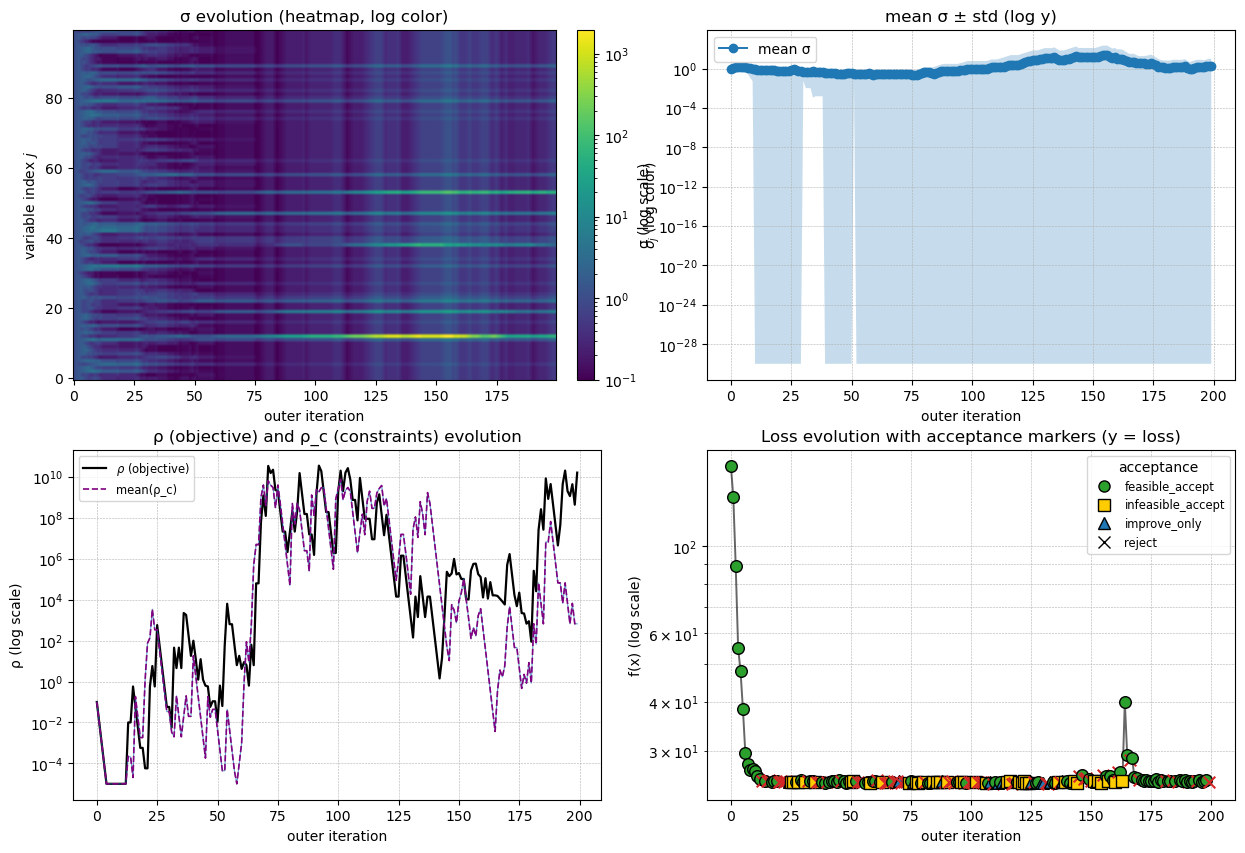

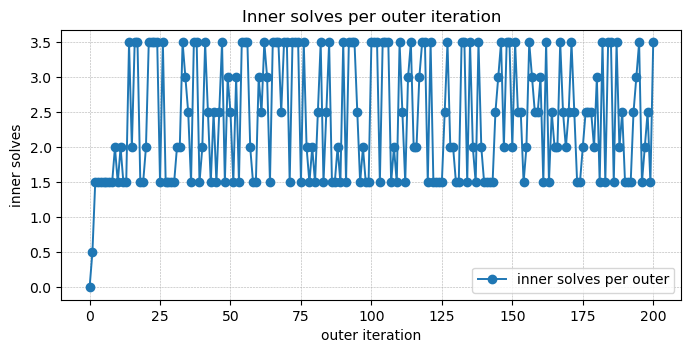


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 2.001e+00, final std = 8.124e+00
Rho (objective): final = 1.623e+10
Rho_c (constraints): shape = (200, 1), final mean = 6.621e+02

Acceptance counts:
Counter({'feasible_accept': 91, 'reject': 55, 'infeasible_accept': 38, 'improve_only': 16})

Average inner solves per outer step (observed): 2.40
CCSA σ=0.1: cumulative_wval=163.216, weighted_evals=483.5, x_history_len=201
CSSCA (tau_obj=0.03, tau_cons=0.03, rho=1.0): last f=84.9723, last g[0]=-2.83334
CSSCA (tau_obj=0.1, tau_cons=0.1, rho=1.0): last f=25, last g[0]=8.61533e-12
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=25, last g[0]=-2.43716e-12
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=27.4058, last g[0]=-0.0020095


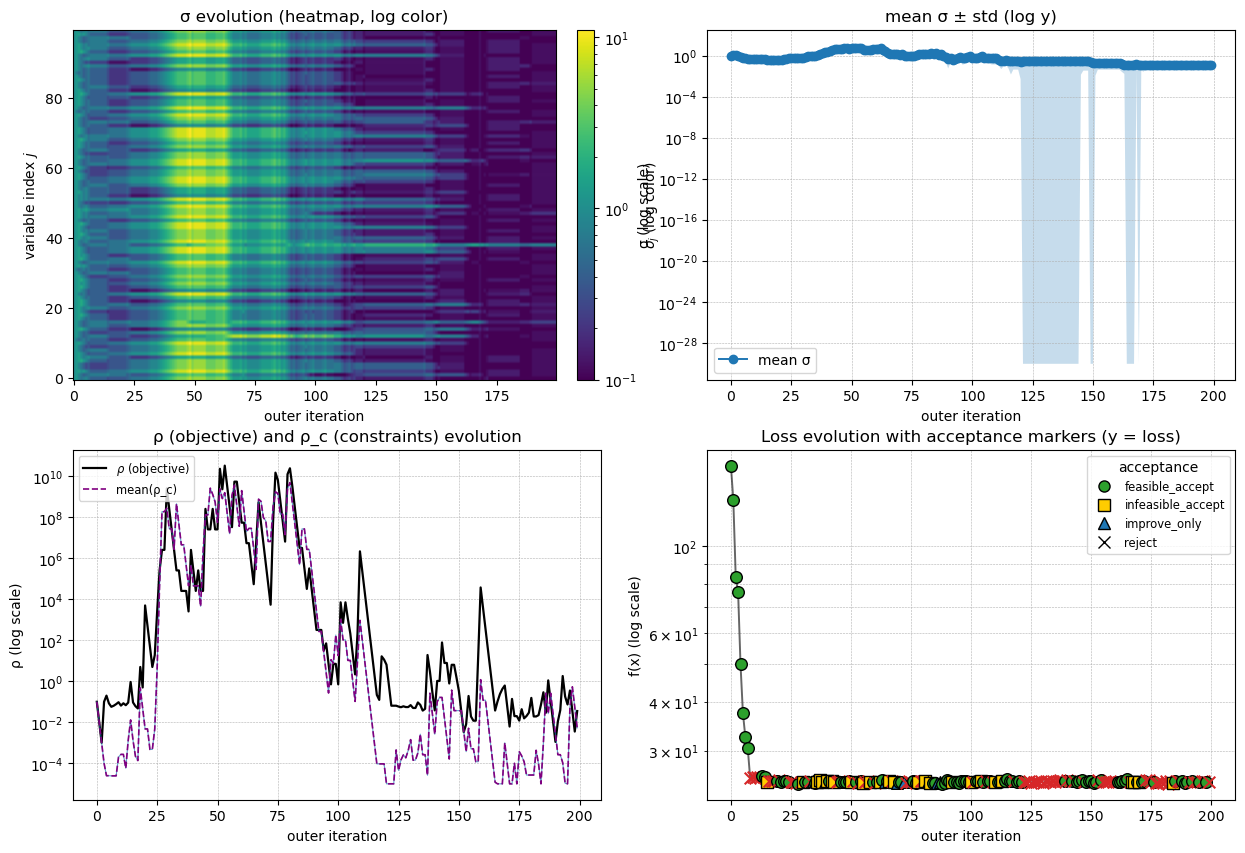

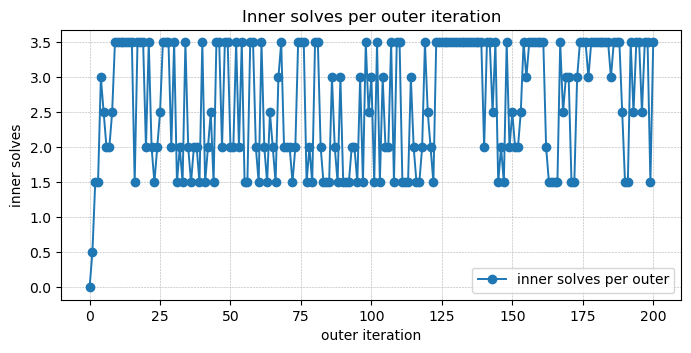


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.243e-01, final std = 6.501e-02
Rho (objective): final = 3.533e-02
Rho_c (constraints): shape = (200, 1), final mean = 5.358e-03

Acceptance counts:
Counter({'feasible_accept': 88, 'reject': 78, 'infeasible_accept': 26, 'improve_only': 8})

Average inner solves per outer step (observed): 2.61
CCSA σ=0.1: cumulative_wval=295.981, weighted_evals=526.0, x_history_len=201


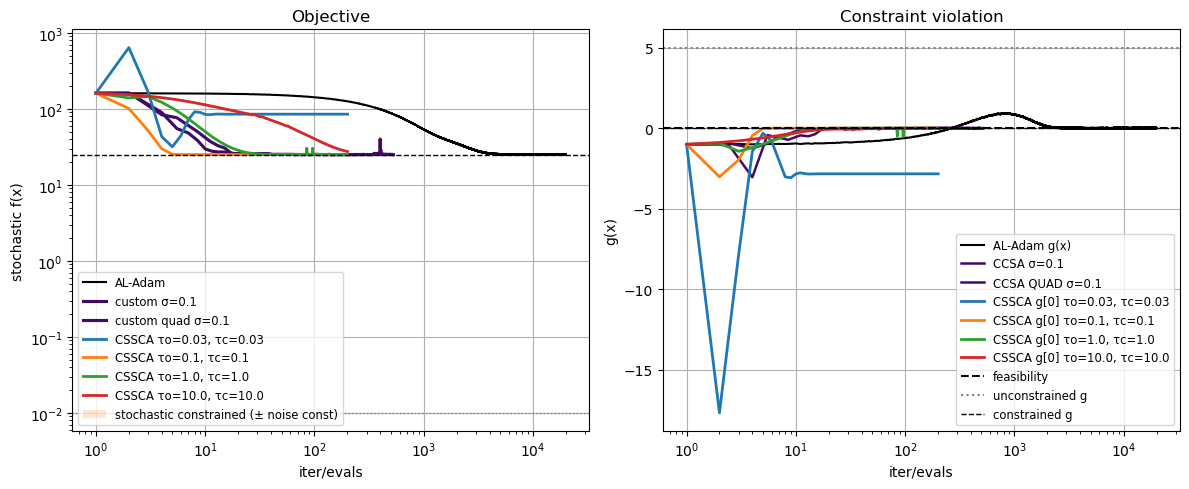

In [3]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments import stoch_convex_con_exp

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.03, 0.1, 1.0, 10.0], cssca_tau_cons=[0.03, 0.1, 1.0, 10.0])

=== Running noise = 0.01, cond# = 100 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=10.8753, λ*=0.0160915
  E[f(x*)]=0.0413543 (noise const=0.00112555)
Unconstrained baseline: E[f(x_uncon)]= 0.00112555, g(x_uncon)=5
Initial constraint g(x0)=-0.895779 (init_feasible=True)

AL-Adam finished:
  last f_est=0.0426151, g(x)=0.0211965, λ=0.0331538

nlopt σ=0.1: res=5, ||x||=10.3, g(x)=0.00858


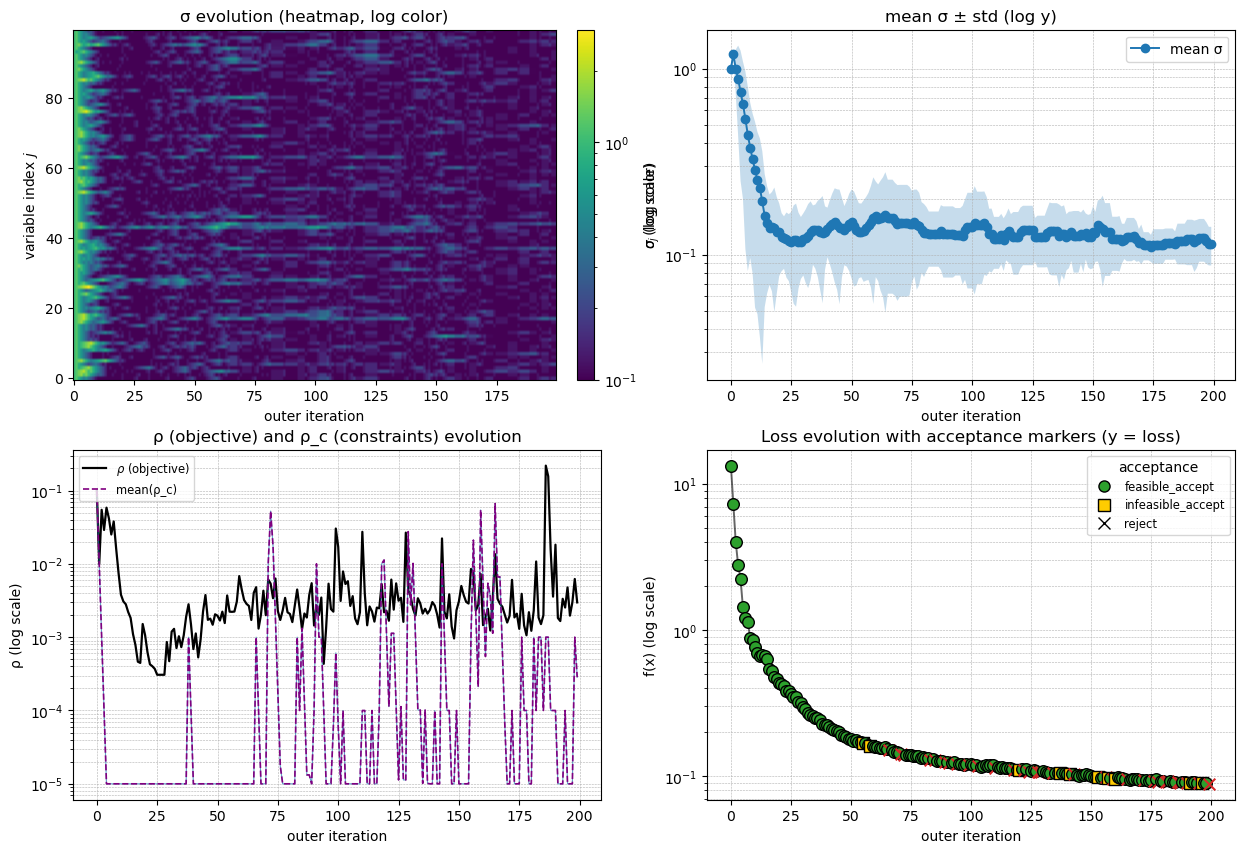

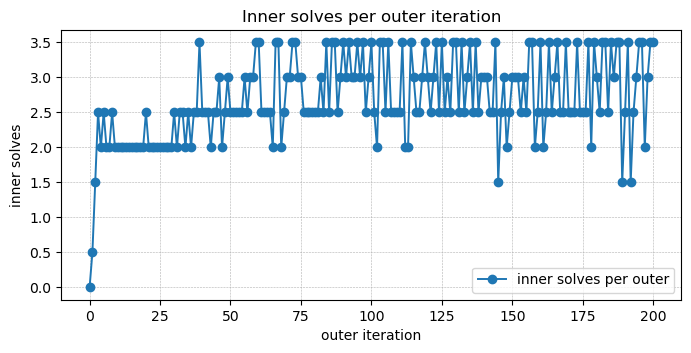


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.145e-01, final std = 2.686e-02
Rho (objective): final = 2.981e-03
Rho_c (constraints): shape = (200, 1), final mean = 2.847e-04

Acceptance counts:
Counter({'feasible_accept': 159, 'reject': 31, 'infeasible_accept': 10})

Average inner solves per outer step (observed): 2.69
CCSA σ=0.1: cumulative_wval=138.307, weighted_evals=541.5, x_history_len=201
CSSCA (tau_obj=0.3, tau_cons=0.3, rho=1.0): last f=36.0388, last g[0]=-45.9944
CSSCA (tau_obj=0.5, tau_cons=0.5, rho=1.0): last f=0.0690546, last g[0]=-8.73078e-05
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=0.107998, last g[0]=-0.000193606
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=0.63974, last g[0]=-0.00102114


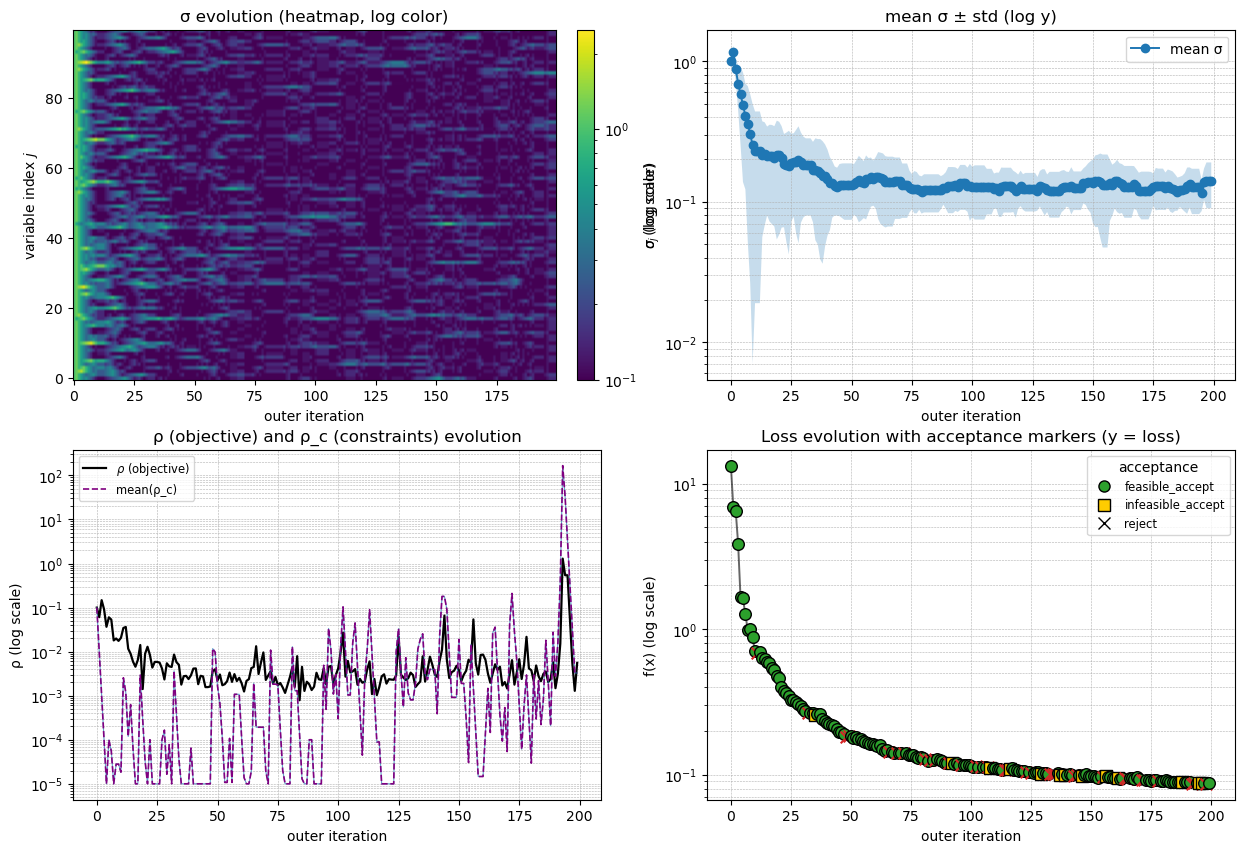

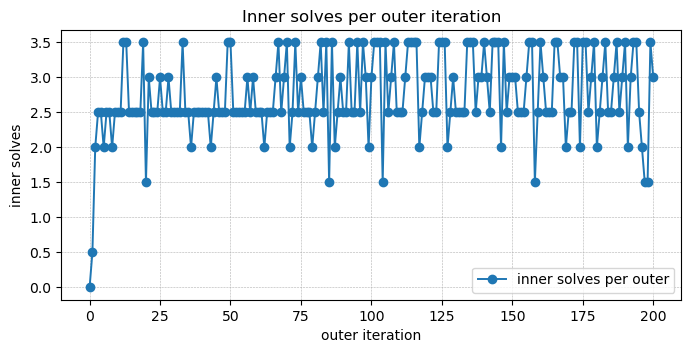


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.403e-01, final std = 5.019e-02
Rho (objective): final = 5.555e-03
Rho_c (constraints): shape = (200, 1), final mean = 3.273e-03

Acceptance counts:
Counter({'feasible_accept': 154, 'reject': 33, 'infeasible_accept': 13})

Average inner solves per outer step (observed): 2.74
CCSA σ=0.1: cumulative_wval=78.0545, weighted_evals=552.5, x_history_len=201


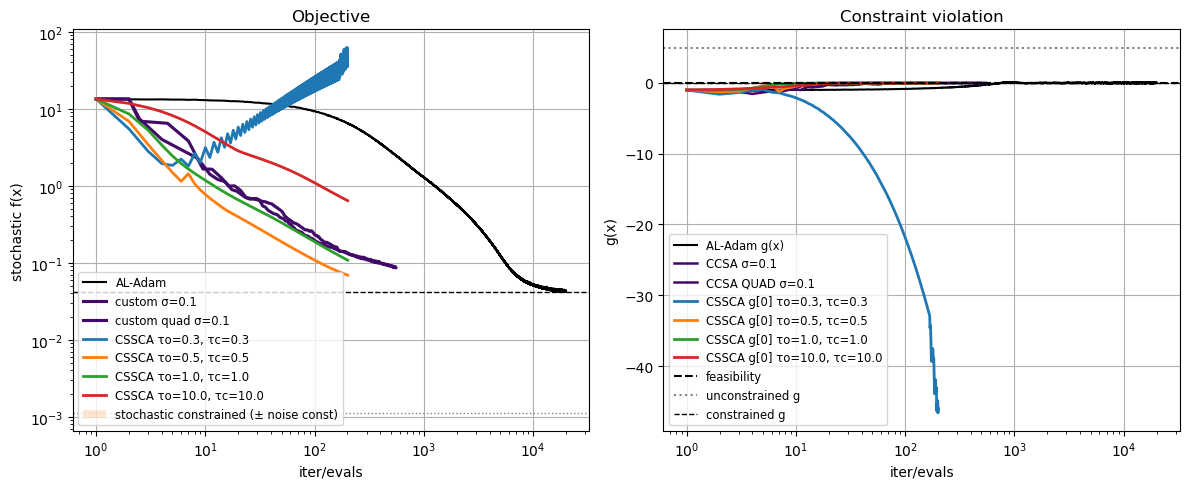

In [4]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments import stoch_convex_con_exp

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [100]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.3, 0.5, 1.0, 10.0], cssca_tau_cons=[0.3, 0.5, 1.0, 10.0])

=== Running noise = 0.1, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=26 (noise const=1)
Unconstrained baseline: E[f(x_uncon)]= 1, g(x_uncon)=5
Initial constraint g(x0)=0.0422118 (init_feasible=True)

AL-Adam finished:
  last f_est=27.0444, g(x)=0.196526, λ=10.0476

nlopt σ=0.1: res=5, ||x||=5.05, g(x)=0.114


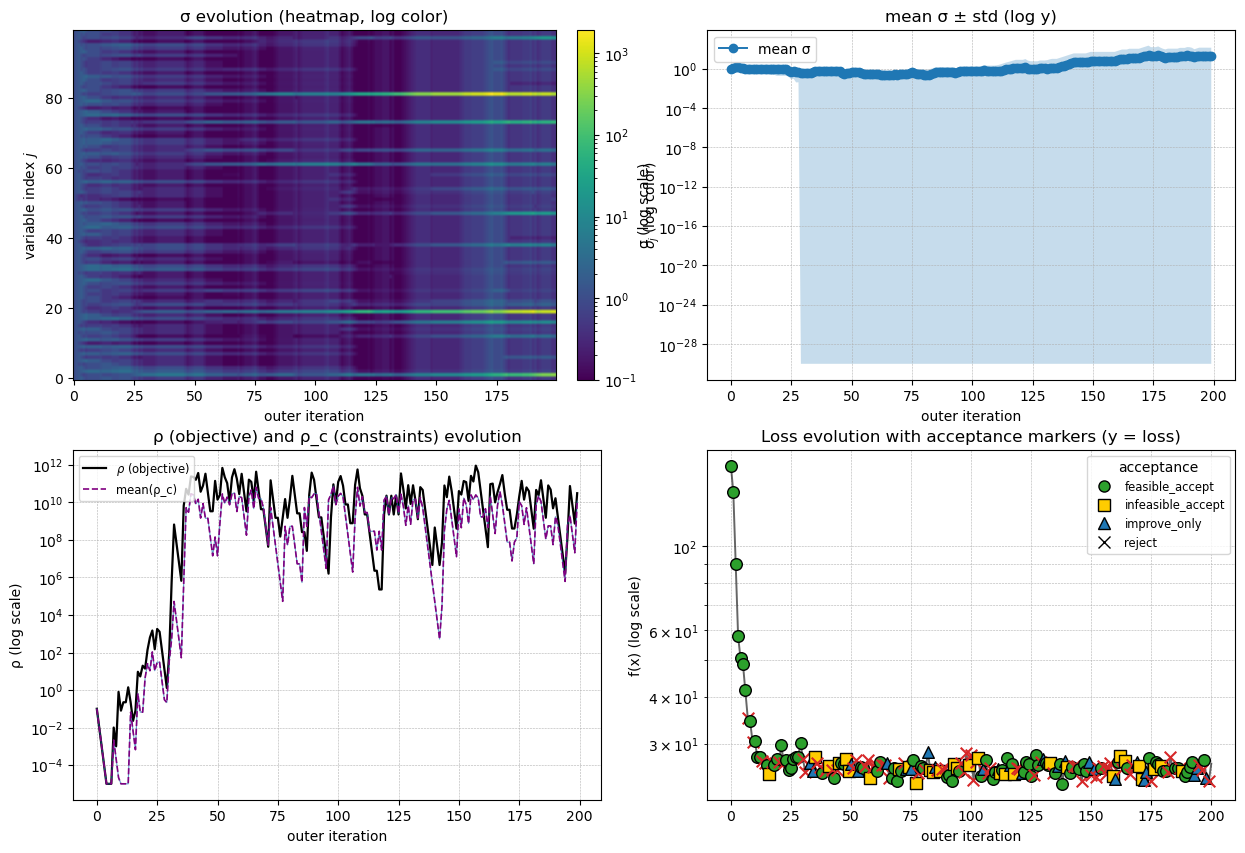

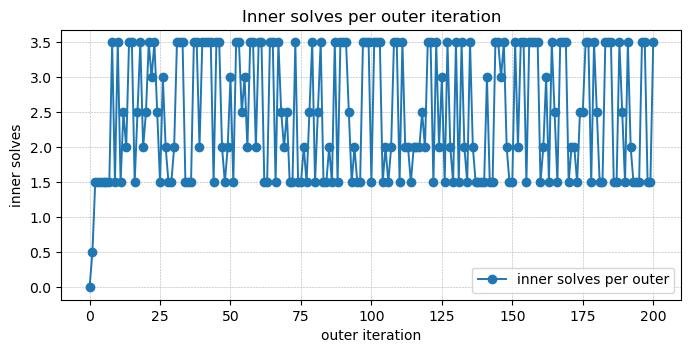


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 2.061e+01, final std = 1.178e+02
Rho (objective): final = 3.105e+10
Rho_c (constraints): shape = (200, 1), final mean = 1.166e+10

Acceptance counts:
Counter({'feasible_accept': 79, 'reject': 66, 'infeasible_accept': 30, 'improve_only': 25})

Average inner solves per outer step (observed): 2.45
CCSA σ=0.1: cumulative_wval=149.73, weighted_evals=493.5, x_history_len=201
CSSCA (tau_obj=0.3, tau_cons=0.3, rho=1.0): last f=25, last g[0]=-4.28431e-11
CSSCA (tau_obj=0.5, tau_cons=0.5, rho=1.0): last f=25, last g[0]=-2.71188e-11
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=25, last g[0]=-2.43716e-12
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=27.4058, last g[0]=-0.0020095


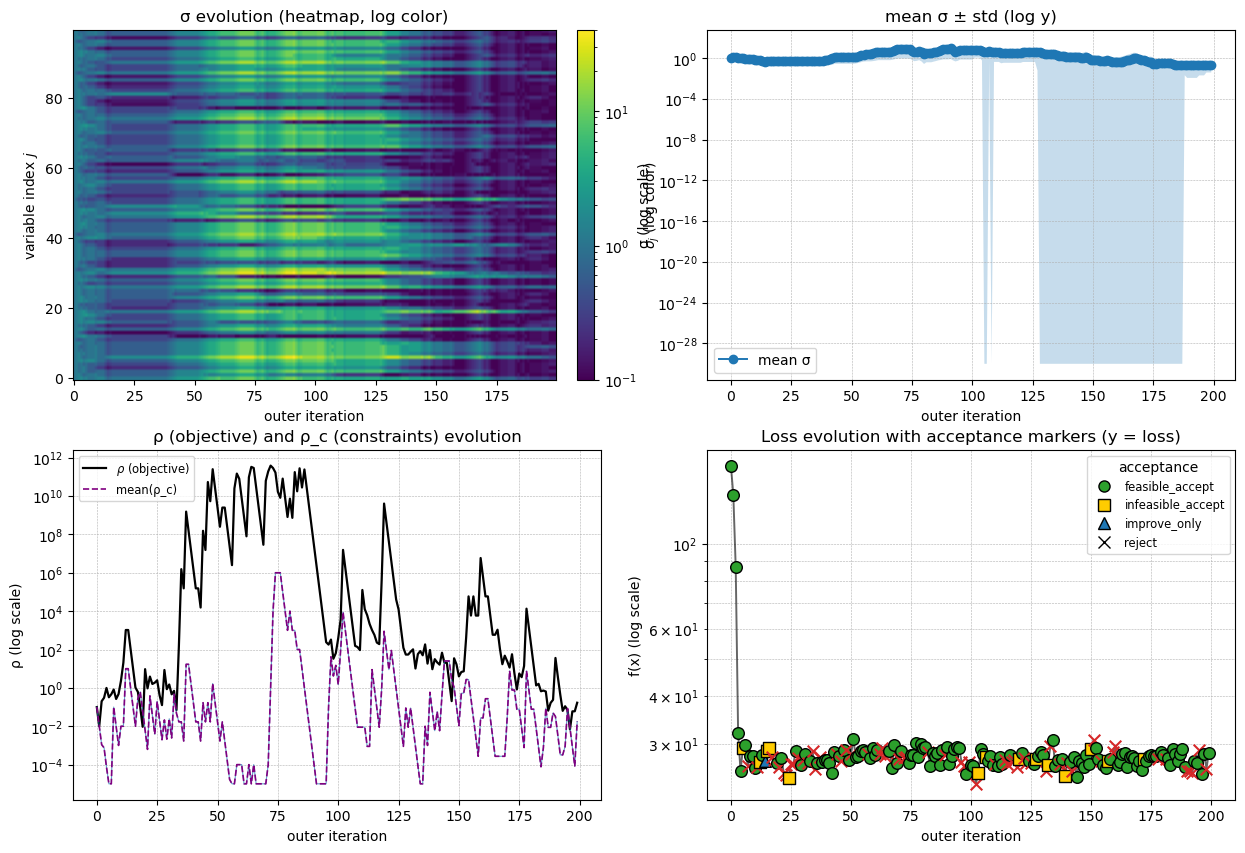

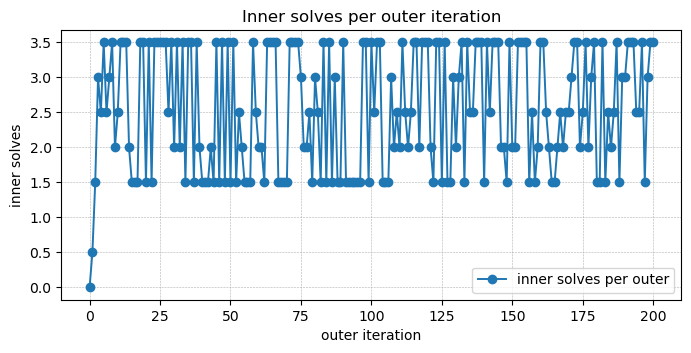


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.962e-01, final std = 1.568e-01
Rho (objective): final = 1.682e-01
Rho_c (constraints): shape = (200, 1), final mean = 1.764e-02

Acceptance counts:
Counter({'feasible_accept': 127, 'reject': 58, 'infeasible_accept': 14, 'improve_only': 1})

Average inner solves per outer step (observed): 2.54
CCSA σ=0.1: cumulative_wval=52.439, weighted_evals=512.5, x_history_len=201


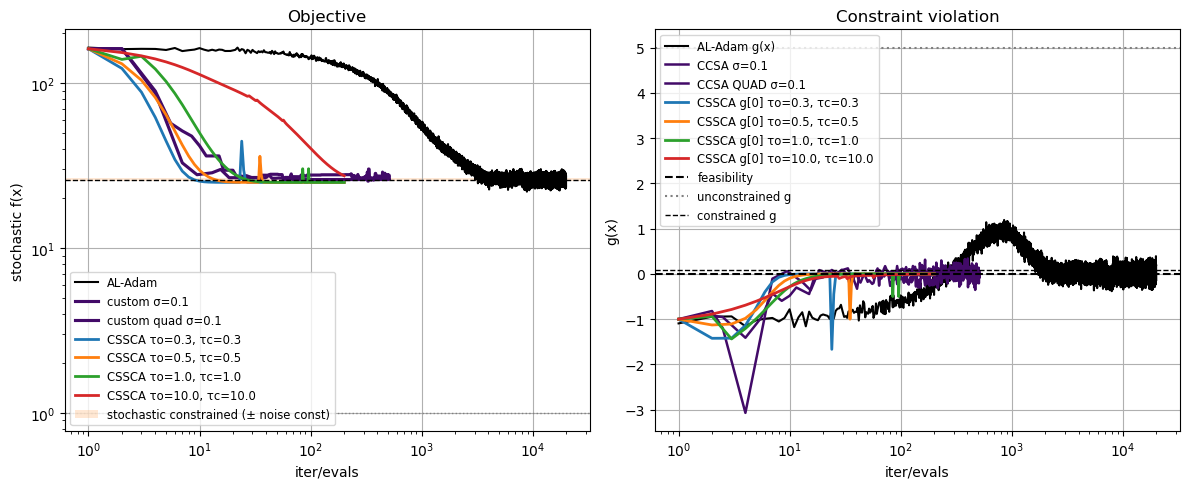

In [12]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments import stoch_convex_con_exp

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.1]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.3, 0.5, 1.0, 10.0], cssca_tau_cons=[0.3, 0.5, 1.0, 10.0])

If we make the constraint stochastic then there is an issue related to the respect of this constraint. MMA fails because of it